In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("C:\\project2\\Data-Analytics-Project2\\data\\sales.csv")
df.head()

C:\Users\admin\AppData\Local\Temp\ipykernel_724\2498604383.py:1: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("C:\\project2\\Data-Analytics-Project2\\data\\sales.csv")


,order_id,order_date,status,item_id,sku,qty_ordered,price,discount_amount,category,payment_method,...,Customer Since,SSN,Phone No.,Place Name,County,City,State,Zip,Region,User Name
0,100354678,01-10-2020,received,574772,oasis_Oasis-064-36,21,89.9,0.0,Men's Fashion,cod,...,8/22/2006,627-31-5251,405-959-1129,Vinson,Harmon,Vinson,OK,73571,South,jwtitus
1,100354678,01-10-2020,received,574774,Fantastic_FT-48,11,19.0,0.0,Men's Fashion,cod,...,8/22/2006,627-31-5251,405-959-1129,Vinson,Harmon,Vinson,OK,73571,South,jwtitus
2,100354680,01-10-2020,complete,574777,mdeal_DMC-610-8,9,149.9,0.0,Men's Fashion,cod,...,8/22/2006,627-31-5251,405-959-1129,Vinson,Harmon,Vinson,OK,73571,South,jwtitus
3,100354680,01-10-2020,complete,574779,oasis_Oasis-061-36,9,79.9,0.0,Men's Fashion,cod,...,8/22/2006,627-31-5251,405-959-1129,Vinson,Harmon,Vinson,OK,73571,South,jwtitus
4,100367357,13-11-2020,received,595185,MEFNAR59C38B6CA08CD,2,99.9,0.0,Men's Fashion,cod,...,8/22/2006,627-31-5251,405-959-1129,Vinson,Harmon,Vinson,OK,73571,South,jwtitus


In [3]:
df.isnull().sum()

order_id           0
order_date         0
status             0
item_id            0
sku                0
qty_ordered        0
price              0
discount_amount    0
category           0
payment_method     0
bi_st              0
cust_id            0
year               0
month              0
ref_num            0
Name Prefix        0
First Name         0
Middle Initial     0
Last Name          0
Gender             0
age                0
full_name          0
E Mail             0
Customer Since     0
SSN                0
Phone No.          0
Place Name         0
County             0
City               0
State              0
Zip                0
Region             0
User Name          0
dtype: int64

In [4]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [5]:
# Convert Date Columns
df["order_date"] = pd.to_datetime(
    df["order_date"],
    errors="coerce",
    dayfirst=True
)

df["Customer Since"] = pd.to_datetime(
    df["Customer Since"],
    errors="coerce"
)

In [6]:
df.dtypes


order_id                   object
order_date         datetime64[ns]
status                     object
item_id                     int64
sku                        object
qty_ordered                 int64
price                     float64
discount_amount           float64
category                   object
payment_method             object
bi_st                      object
cust_id                     int64
year                        int64
month                      object
ref_num                     int64
Name Prefix                object
First Name                 object
Middle Initial             object
Last Name                  object
Gender                     object
age                         int64
full_name                  object
E Mail                     object
Customer Since     datetime64[ns]
SSN                        object
Phone No.                  object
Place Name                 object
County                     object
City                       object
State         

In [7]:
df[["order_date", "Customer Since"]].head()

,order_date,Customer Since
0,2020-10-01,2006-08-22
1,2020-10-01,2006-08-22
2,2020-10-01,2006-08-22
3,2020-10-01,2006-08-22
4,2020-11-13,2006-08-22


In [8]:
df[["order_date", "Customer Since"]].isnull().sum()

order_date             0
Customer Since    111104
dtype: int64

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 286392 entries, 0 to 286391
Data columns (total 33 columns):
 #   Column           Non-Null Count   Dtype         
---  ------           --------------   -----         
 0   order_id         286392 non-null  object        
 1   order_date       286392 non-null  datetime64[ns]
 2   status           286392 non-null  object        
 3   item_id          286392 non-null  int64         
 4   sku              286392 non-null  object        
 5   qty_ordered      286392 non-null  int64         
 6   price            286392 non-null  float64       
 7   discount_amount  286392 non-null  float64       
 8   category         286392 non-null  object        
 9   payment_method   286392 non-null  object        
 10  bi_st            286392 non-null  object        
 11  cust_id          286392 non-null  int64         
 12  year             286392 non-null  int64         
 13  month            286392 non-null  object        
 14  ref_num          286

In [10]:
df.shape

(286392, 33)

In [11]:
df["order_date"] = pd.to_datetime(df["order_date"], errors="coerce")
df["Customer Since"] = pd.to_datetime(df["Customer Since"], errors="coerce")

In [12]:
df["Sales"] = (df["qty_ordered"] * df["price"]) - df["discount_amount"]

df[["qty_ordered", "price", "discount_amount", "Sales"]].head()

,qty_ordered,price,discount_amount,Sales
0,21,89.9,0.0,1887.9
1,11,19.0,0.0,209.0
2,9,149.9,0.0,1349.1
3,9,79.9,0.0,719.1
4,2,99.9,0.0,199.8


In [13]:
df.describe()

,order_date,item_id,qty_ordered,price,discount_amount,cust_id,year,ref_num,age,Customer Since,Zip,Sales
count,286392,286392.000000,286392.000000,286392.000000,286392.000000,286392.000000,286392.000000,286392.000000,286392.000000,175288,286392.000000,286392.000000
mean,2021-03-12 11:18:32.008715264,741664.902131,3.011296,851.385253,70.039427,70048.019054,2020.618778,560853.663395,46.489033,2007-11-04 18:25:55.602209280,49723.160015,1667.225760
min,2020-10-01 00:00:00,574769.000000,1.000000,0.000000,0.000000,4.000000,2020.000000,111127.000000,18.000000,1978-11-30 00:00:00,210.000000,0.000000
25%,2020-12-24 00:00:00,659684.500000,2.000000,49.900000,0.000000,56519.000000,2020.000000,341265.000000,32.000000,2002-10-17 00:00:00,26571.750000,119.800000
50%,2021-03-16 00:00:00,742309.000000,2.000000,119.000000,0.000000,74225.500000,2021.000000,564857.000000,47.000000,2010-03-21 00:00:00,49316.000000,313.967000
75%,2021-05-18 00:00:00,826124.250000,3.000000,950.000000,18.383050,92357.000000,2021.000000,781086.000000,61.000000,2015-01-17 00:00:00,72645.000000,1935.000000
max,2021-09-30 00:00:00,905208.000000,501.000000,101262.590000,30213.150000,115326.000000,2021.000000,999981.000000,75.000000,2017-07-28 00:00:00,99950.000000,202525.180000
std,NaN,95746.031827,4.573837,1741.750751,256.880870,30243.856395,0.485688,255828.418398,16.673288,NaN,27597.198873,3506.053973


In [14]:
total_revenue = df["Sales"].sum()

print(f"Total Revenue: ₹{total_revenue:,.2f}")

Total Revenue: ₹477,480,119.92


In [15]:
total_orders = df["order_id"].nunique()

print("Total Orders:", total_orders)

Total Orders: 201716


In [16]:
total_customers = df["cust_id"].nunique()

print("Total Customers:", total_customers)

Total Customers: 64248


In [17]:
average_order_value = total_revenue / total_orders

print(f"Average Order Value: ₹{average_order_value:.2f}")

Average Order Value: ₹2367.09


In [18]:
df["status"].value_counts()

status
canceled          112166
complete           88968
received           51775
order_refunded     25713
refund              3820
cod                 2851
paid                 756
closed               176
payment_review        57
pending               48
processing            33
holded                25
pending_paypal         4
Name: count, dtype: int64

In [19]:
df["category"].value_counts().head(10)

category
Mobiles & Tablets    61761
Men's Fashion        40713
Appliances           33034
Women's Fashion      28334
Others               26108
Beauty & Grooming    17899
Entertainment        17352
Superstore           15024
Home & Living        13990
Health & Sports       8421
Name: count, dtype: int64

In [20]:
df["payment_method"].value_counts()

payment_method
cod                  102916
Easypay               69679
Payaxis               31049
easypay_voucher       29763
bankalfalah           23057
Easypay_MA            11536
jazzwallet             6669
jazzvoucher            6045
customercredit         3702
apg                    1758
mcblite                 208
cashatdoorstep            9
financesettlement         1
Name: count, dtype: int64

In [21]:
df["State"].value_counts().head(10)

State
TX    17510
CA    17130
NY    15567
PA    14394
IL    12628
FL    10538
OH    10204
MO     8876
VA     8557
IA     8170
Name: count, dtype: int64

In [22]:
df["City"].value_counts().head(10)

City
Dekalb           2525
Washington       2008
New York City    1391
Houston          1250
El Paso          1019
Atlanta           999
Dallas            838
Springfield       817
Albany            726
Kittanning        716
Name: count, dtype: int64

In [23]:
print("----- Business Insights -----")
print(f"Total Revenue       : ₹{total_revenue:,.2f}")
print(f"Total Orders        : {total_orders}")
print(f"Total Customers     : {total_customers}")
print(f"Average Order Value : ₹{average_order_value:.2f}")

----- Business Insights -----
Total Revenue       : ₹477,480,119.92
Total Orders        : 201716
Total Customers     : 64248
Average Order Value : ₹2367.09


In [24]:
cohort_df = df[["cust_id", "order_id", "order_date"]].copy()

cohort_df.head()

,cust_id,order_id,order_date
0,60124,100354678,2020-10-01
1,60124,100354678,2020-10-01
2,60124,100354680,2020-10-01
3,60124,100354680,2020-10-01
4,60124,100367357,2020-11-13


In [25]:
cohort_df = cohort_df.dropna(subset=["order_date"])

cohort_df.shape

(286392, 3)

In [26]:
# Create Order Month
cohort_df["OrderMonth"] = cohort_df["order_date"].dt.to_period("M")

cohort_df.head()

,cust_id,order_id,order_date,OrderMonth
0,60124,100354678,2020-10-01,2020-10
1,60124,100354678,2020-10-01,2020-10
2,60124,100354680,2020-10-01,2020-10
3,60124,100354680,2020-10-01,2020-10
4,60124,100367357,2020-11-13,2020-11


In [27]:
# Find First Purchase Month
cohort_df["CohortMonth"] = cohort_df.groupby("cust_id")["OrderMonth"].transform("min")

cohort_df.head()

,cust_id,order_id,order_date,OrderMonth,CohortMonth
0,60124,100354678,2020-10-01,2020-10,2020-10
1,60124,100354678,2020-10-01,2020-10,2020-10
2,60124,100354680,2020-10-01,2020-10,2020-10
3,60124,100354680,2020-10-01,2020-10,2020-10
4,60124,100367357,2020-11-13,2020-11,2020-10


In [28]:
cohort_df.sample(10)

,cust_id,order_id,order_date,OrderMonth,CohortMonth
268334,110145,100537770,2021-07-04,2021-07,2021-07
130235,75652,100409081,2020-12-26,2020-12,2020-12
143999,78546,100419053,2020-12-27,2020-12,2020-12
62781,65018,100536928,2021-07-02,2021-07,2020-11
169498,84327,100441394,2021-02-01,2021-02,2021-02
171219,84759,100524260,2021-06-11,2021-06,2021-02
112864,35081,100538055,2021-07-04,2021-07,2020-12
28439,61464,100359680,2020-10-25,2020-10,2020-10
61219,42517,100449961,2021-03-06,2021-03,2020-11
100011,45883,100429150,2020-12-30,2020-12,2020-12


In [29]:
# order year and month created
cohort_df["OrderYear"] = cohort_df["OrderMonth"].dt.year
cohort_df["OrderMonthNum"] = cohort_df["OrderMonth"].dt.month


cohort_df["CohortYear"] = cohort_df["CohortMonth"].dt.year
cohort_df["CohortMonthNum"] = cohort_df["CohortMonth"].dt.month

In [30]:
# Calculate Cohort Index
year_diff = cohort_df["OrderYear"] - cohort_df["CohortYear"]
month_diff = cohort_df["OrderMonthNum"] - cohort_df["CohortMonthNum"]

cohort_df["CohortIndex"] = year_diff *12 + month_diff +1
cohort_df.head()

,cust_id,order_id,order_date,OrderMonth,CohortMonth,OrderYear,OrderMonthNum,CohortYear,CohortMonthNum,CohortIndex
0,60124,100354678,2020-10-01,2020-10,2020-10,2020,10,2020,10,1
1,60124,100354678,2020-10-01,2020-10,2020-10,2020,10,2020,10,1
2,60124,100354680,2020-10-01,2020-10,2020-10,2020,10,2020,10,1
3,60124,100354680,2020-10-01,2020-10,2020-10,2020,10,2020,10,1
4,60124,100367357,2020-11-13,2020-11,2020-10,2020,11,2020,10,2


In [31]:
cohort_df[["cust_id","OrderMonth","CohortMonth","CohortIndex"]].head(15)

,cust_id,OrderMonth,CohortMonth,CohortIndex
0,60124,2020-10,2020-10,1
1,60124,2020-10,2020-10,1
2,60124,2020-10,2020-10,1
3,60124,2020-10,2020-10,1
4,60124,2020-11,2020-10,2
5,60124,2020-11,2020-10,2
6,60124,2020-11,2020-10,2
7,42485,2020-10,2020-10,1
8,42485,2020-10,2020-10,1
9,42485,2020-10,2020-10,1


In [32]:
cohort_data=(
    cohort_df.groupby(["CohortMonth","CohortIndex"])["cust_id"].nunique().reset_index()
)
cohort_data.head()

,CohortMonth,CohortIndex,cust_id
0,2020-10,1,3165
1,2020-10,2,810
2,2020-10,3,758
3,2020-10,4,322
4,2020-10,5,253


In [33]:
retention_matrix = cohort_data.pivot(
    index="CohortMonth",
    columns="CohortIndex",
    values="cust_id"
)

retention_matrix

CohortIndex,1,2,3,4,5,6,7,8,9,10,11,12
CohortMonth,,,,,,,,,,,,
2020-10,3165.0,810.0,758.0,322.0,253.0,334.0,302.0,197.0,290.0,163.0,123.0,173.0
2020-11,4541.0,989.0,307.0,190.0,363.0,306.0,177.0,336.0,151.0,108.0,148.0,NaN
2020-12,19831.0,1712.0,681.0,905.0,1003.0,510.0,905.0,403.0,285.0,411.0,NaN,NaN
2021-01,3047.0,227.0,164.0,144.0,91.0,111.0,81.0,69.0,73.0,NaN,NaN,NaN
2021-02,2015.0,209.0,129.0,76.0,86.0,49.0,36.0,42.0,NaN,NaN,NaN,NaN
2021-03,6039.0,882.0,221.0,376.0,124.0,78.0,123.0,NaN,NaN,NaN,NaN,NaN
2021-04,11546.0,652.0,424.0,161.0,113.0,132.0,NaN,NaN,NaN,NaN,NaN,NaN
2021-05,3617.0,262.0,137.0,86.0,69.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-06,4333.0,325.0,164.0,168.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [34]:
# Calculate retention rate
retention_rate = retention_matrix.divide(
    retention_matrix.iloc[:,0],
    axis=0
)

retention_rate = retention_rate.round(3)

retention_rate

CohortIndex,1,2,3,4,5,6,7,8,9,10,11,12
CohortMonth,,,,,,,,,,,,
2020-10,1.0,0.256,0.239,0.102,0.080,0.106,0.095,0.062,0.092,0.052,0.039,0.055
2020-11,1.0,0.218,0.068,0.042,0.080,0.067,0.039,0.074,0.033,0.024,0.033,NaN
2020-12,1.0,0.086,0.034,0.046,0.051,0.026,0.046,0.020,0.014,0.021,NaN,NaN
2021-01,1.0,0.074,0.054,0.047,0.030,0.036,0.027,0.023,0.024,NaN,NaN,NaN
2021-02,1.0,0.104,0.064,0.038,0.043,0.024,0.018,0.021,NaN,NaN,NaN,NaN
2021-03,1.0,0.146,0.037,0.062,0.021,0.013,0.020,NaN,NaN,NaN,NaN,NaN
2021-04,1.0,0.056,0.037,0.014,0.010,0.011,NaN,NaN,NaN,NaN,NaN,NaN
2021-05,1.0,0.072,0.038,0.024,0.019,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-06,1.0,0.075,0.038,0.039,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [35]:
# Percentage Conversion
retention_percentage = retention_rate * 100

retention_percentage.round(2)

CohortIndex,1,2,3,4,5,6,7,8,9,10,11,12
CohortMonth,,,,,,,,,,,,
2020-10,100.0,25.6,23.9,10.2,8.0,10.6,9.5,6.2,9.2,5.2,3.9,5.5
2020-11,100.0,21.8,6.8,4.2,8.0,6.7,3.9,7.4,3.3,2.4,3.3,NaN
2020-12,100.0,8.6,3.4,4.6,5.1,2.6,4.6,2.0,1.4,2.1,NaN,NaN
2021-01,100.0,7.4,5.4,4.7,3.0,3.6,2.7,2.3,2.4,NaN,NaN,NaN
2021-02,100.0,10.4,6.4,3.8,4.3,2.4,1.8,2.1,NaN,NaN,NaN,NaN
2021-03,100.0,14.6,3.7,6.2,2.1,1.3,2.0,NaN,NaN,NaN,NaN,NaN
2021-04,100.0,5.6,3.7,1.4,1.0,1.1,NaN,NaN,NaN,NaN,NaN,NaN
2021-05,100.0,7.2,3.8,2.4,1.9,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-06,100.0,7.5,3.8,3.9,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [36]:
retention_percentage = retention_percentage.fillna(0)

retention_percentage.round(2)

CohortIndex,1,2,3,4,5,6,7,8,9,10,11,12
CohortMonth,,,,,,,,,,,,
2020-10,100.0,25.6,23.9,10.2,8.0,10.6,9.5,6.2,9.2,5.2,3.9,5.5
2020-11,100.0,21.8,6.8,4.2,8.0,6.7,3.9,7.4,3.3,2.4,3.3,0.0
2020-12,100.0,8.6,3.4,4.6,5.1,2.6,4.6,2.0,1.4,2.1,0.0,0.0
2021-01,100.0,7.4,5.4,4.7,3.0,3.6,2.7,2.3,2.4,0.0,0.0,0.0
2021-02,100.0,10.4,6.4,3.8,4.3,2.4,1.8,2.1,0.0,0.0,0.0,0.0
2021-03,100.0,14.6,3.7,6.2,2.1,1.3,2.0,0.0,0.0,0.0,0.0,0.0
2021-04,100.0,5.6,3.7,1.4,1.0,1.1,0.0,0.0,0.0,0.0,0.0,0.0
2021-05,100.0,7.2,3.8,2.4,1.9,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2021-06,100.0,7.5,3.8,3.9,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


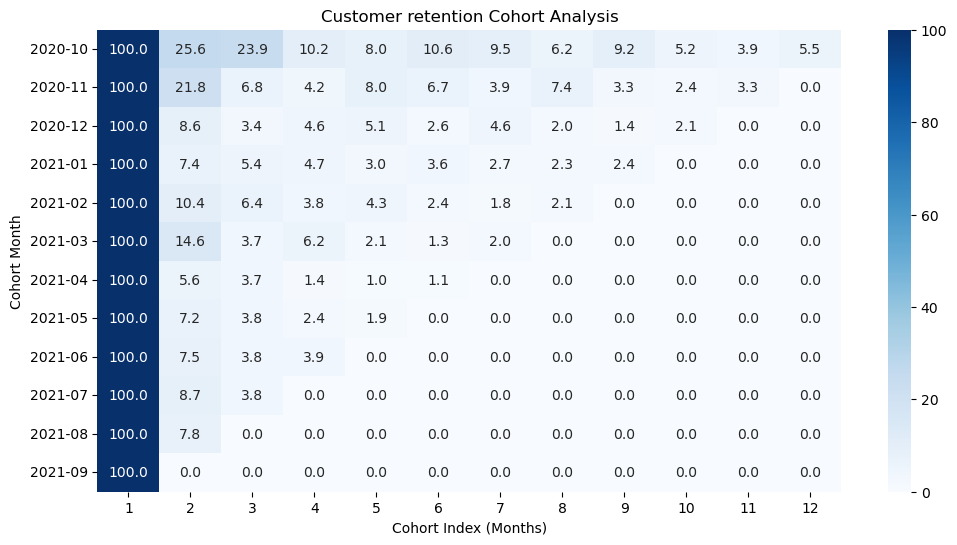

In [37]:
plt.figure(figsize=(12,6))

sns.heatmap(
    retention_percentage,
    annot=True,
    fmt=".1f",
    cmap="Blues"
)
plt.title("Customer retention Cohort Analysis")
plt.xlabel("Cohort Index (Months)")
plt.ylabel("Cohort Month")
plt.show()

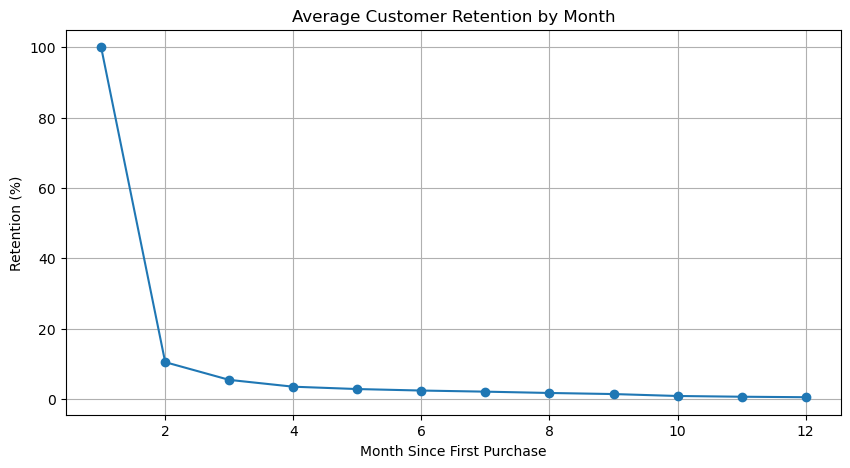

In [38]:
plt.figure(figsize=(10,5))

retention_percentage.mean().plot(
    marker="o"
)

plt.title("Average Customer Retention by Month")
plt.xlabel("Month Since First Purchase")
plt.ylabel("Retention (%)")

plt.grid(True)

plt.show()

In [ ]:
# Highest Retention Cohort
best_cohort = retention_percentage.iloc[:,1].idxmax()

highest_retention = retention_percentage.iloc[:,1].max()

print("Best Cohort:", best_cohort)
print("Highest Month 2 Retention:", round(highest_retention,2), "%")

Best Cohort: 2020-10
Highest Month 2 Retention: 25.6 %


In [40]:
# Lowest Retention Cohort
worst_cohort = retention_percentage.iloc[:,1].idxmin()

lowest_retention = retention_percentage.iloc[:,1].min()

print("Worst Cohort:", worst_cohort)
print("Lowest Month 2 Retention:", round(lowest_retention,2), "%")

Worst Cohort: 2021-09
Lowest Month 2 Retention: 0.0 %


In [41]:
# average retention
average_retention = retention_percentage.mean()

print(average_retention.round(2))

CohortIndex
1     100.00
2      10.43
3       5.39
4       3.45
5       2.78
6       2.36
7       2.04
8       1.67
9       1.36
10      0.81
11      0.60
12      0.46
dtype: float64


In [42]:
print("----- Business Insights -----")

print("1. Customer retention decreases after the first purchase.")

print("2. Early cohorts show better retention than later cohorts.")

print("3. Most customers do not return after a few months.")

print("4. Improving customer engagement can increase long-term retention.")

print("5. Loyalty programs and personalized marketing may help reduce churn.")

----- Business Insights -----
1. Customer retention decreases after the first purchase.
2. Early cohorts show better retention than later cohorts.
3. Most customers do not return after a few months.
4. Improving customer engagement can increase long-term retention.
5. Loyalty programs and personalized marketing may help reduce churn.


In [43]:
retention_percentage.to_csv(
    "../data/retention_percentage.csv"
)

print("Retention matrix exported successfully.")

Retention matrix exported successfully.
